# **Denetimsiz Öğrenme**

1. K means Clustering
2. Hierarchical Clustering
3. DBSCAN
4. Gaussian Mixture Model
5. Pca


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jillanisofttech/market-segmentation-in-insurance-unsupervised")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'market-segmentation-in-insurance-unsupervised' dataset.
Path to dataset files: /kaggle/input/market-segmentation-in-insurance-unsupervised


In [ ]:
import os

full_path=os.path.join(path,'ınsurance.csv')

In [ ]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#veri ön işleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# Algoritmalar ( Kümeleme)
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

#Boyut indirme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Değerlendirme Metrikleri

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score


from scipy.cluster.hierarchy import dendrogram, linkage


plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 14
sns.set_style('whitegrid')
print('Herşey hazır')




Herşey hazır


In [ ]:
data =pd.read_csv('customer.csv')
df=data.copy()

In [ ]:
print(f'Veri Seti Boyutu: {df.shape}')
print(f'Sutun sayisi:{len(df.columns)}')
print(f'Satır Sayısı:{len(df)}')


Veri Seti Boyutu: (8950, 18)
Sutun sayisi:18
Satır Sayısı:8950


In [ ]:
#veri seti bilgisi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
#Istatıksel Ozet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [ ]:
print('Eksik değerler')
print('--'*50)
print(df.isnull().sum()[df.isnull().sum()>0])
print(f'toplam eksik değer: {df.isnull().sum().sum()}')
print('--'*50)

Eksik değerler
----------------------------------------------------------------------------------------------------
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
toplam eksik değer: 314
----------------------------------------------------------------------------------------------------


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df_columns =df.columns.str.strip()

In [ ]:
df.set_index('CUST_ID', inplace=True)
imputer = SimpleImputer(strategy='mean')
df_imputed=pd.DataFrame(imputer.fit_transform(df),columns=df.columns, index=df.index)

print('Eksik değerler')
print('--'*50)
print(df_imputed.isnull().sum()[df_imputed.isnull().sum()>0])
print(f'toplam eksik değer: {df_imputed.isnull().sum().sum()}')

Eksik değerler
----------------------------------------------------------------------------------------------------
Series([], dtype: int64)
toplam eksik değer: 0


In [ ]:
scaler= StandardScaler()
x_scaled=scaler.fit_transform(df_imputed)
x_scaled=pd.DataFrame(x_scaled,columns=df_imputed.columns,index=df_imputed.index)

print('Ölçeklenmiş veri seti')
print('--'*50)
x_scaled.head(2)

Ölçeklenmiş veri seti
----------------------------------------------------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-0.310968,-0.525551,0.36068
C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,0.089310,0.234227,0.36068


In [ ]:
df.head(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


## **K means**

Veri setini k adet kümeye ayıran bir algoritma

parametreleri:


*   n_Cluster küme sayısı
*   init  başlangıç seçme yöntemi
*   n_init farklı başlangıçlarla çalıştırma sayısı
*   max_iter maksimum iterasyon sayısı


Küme sayısı belirleme yöntemleri
*  elbow
* silhoutte
*  Davies Bouldin

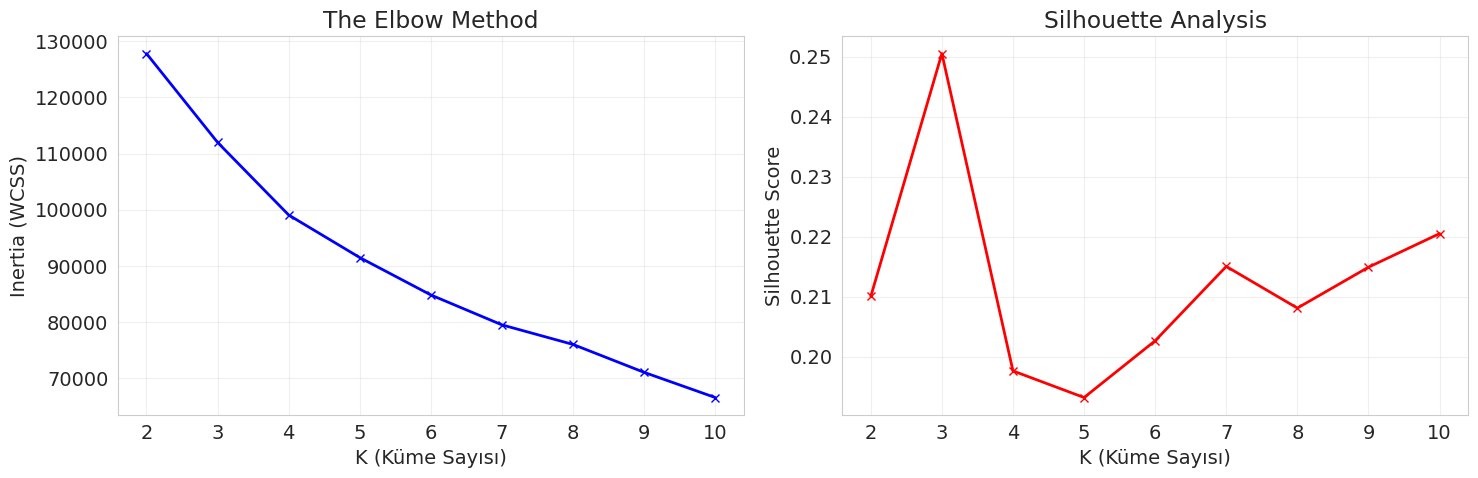

En iyi silhouette skoru: 0.2506
Optimum küme sayısı: 3


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # Fonksiyon tekil

# 1. Listeleri tanımla
inertia = []
silhouette_scores = [] # Liste çoğul
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Değişken adının X_scaled (büyük X) olduğundan emin ol
    labels = kmeans.fit_predict(x_scaled)

    inertia.append(kmeans.inertia_)
    # Liste ismine (çoğul), fonksiyonun (tekil) sonucunu ekle
    silhouette_scores.append(silhouette_score(x_scaled, labels))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol Grafik: Elbow Method
axes[0].plot(K_range, inertia, 'bx-', linewidth=2)
axes[0].set_xlabel('K (Küme Sayısı)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('The Elbow Method')
axes[0].grid(True, alpha=0.3)

# Sağ Grafik: Silhouette Score
# Hata Buradaydı: 'silhouette_score' (fonksiyon) yerine 'silhouette_scores' (liste) olmalı
axes[1].plot(K_range, silhouette_scores, 'rx-', linewidth=2)
axes[1].set_xlabel('K (Küme Sayısı)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# En iyi K değerini hesapla
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum küme sayısı: {optimal_k}')


In [ ]:
# Optimum  K ile  K-Means modelini egit
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42,n_init=10)
kmeans_labels=kmeans.fit_predict(x_scaled)

print('K-means Kümeleme Sonuçları:')
print(f'Kume sayısı: {optimal_k}')
print(f'Silhoutte Skoru: {silhouette_score(x_scaled, kmeans_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, kmeans_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, kmeans_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-means Kümeleme Sonuçları:
Kume sayısı: 4
Silhoutte Skoru: 0.1976
Davies Bouldin Skoru: 1.5752
Calinski Harabasz Skoru: 1597.5222

 Kume dagilimi:
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


In [ ]:
# K-Means kumelerinin ozetleri
df['KMeans_Cluster'] = kmeans_labels
cluster_summary = df.groupby('KMeans_Cluster').mean().round(2)
print('K-Means Kume Profilleri:')
cluster_summary

K-Means Kume Profilleri:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,646.02,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1985.04,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2020.80,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.40,974.51,569.00,0.08,11.45


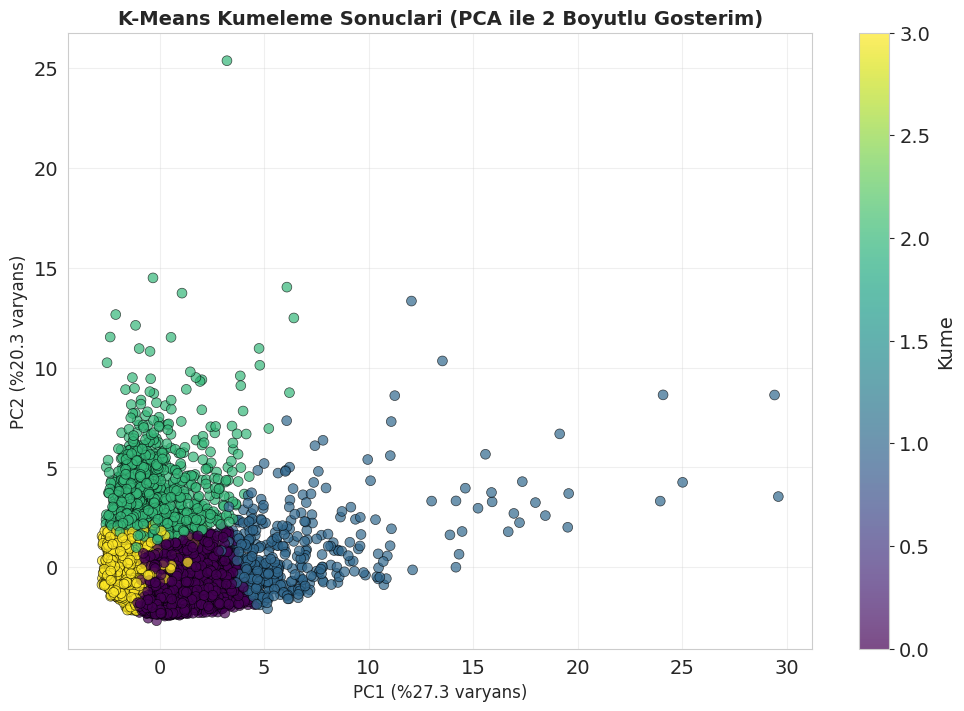

In [ ]:
# PCA ile K-Means gorsellestirmesi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# **Hiyerarşik kümeleme**

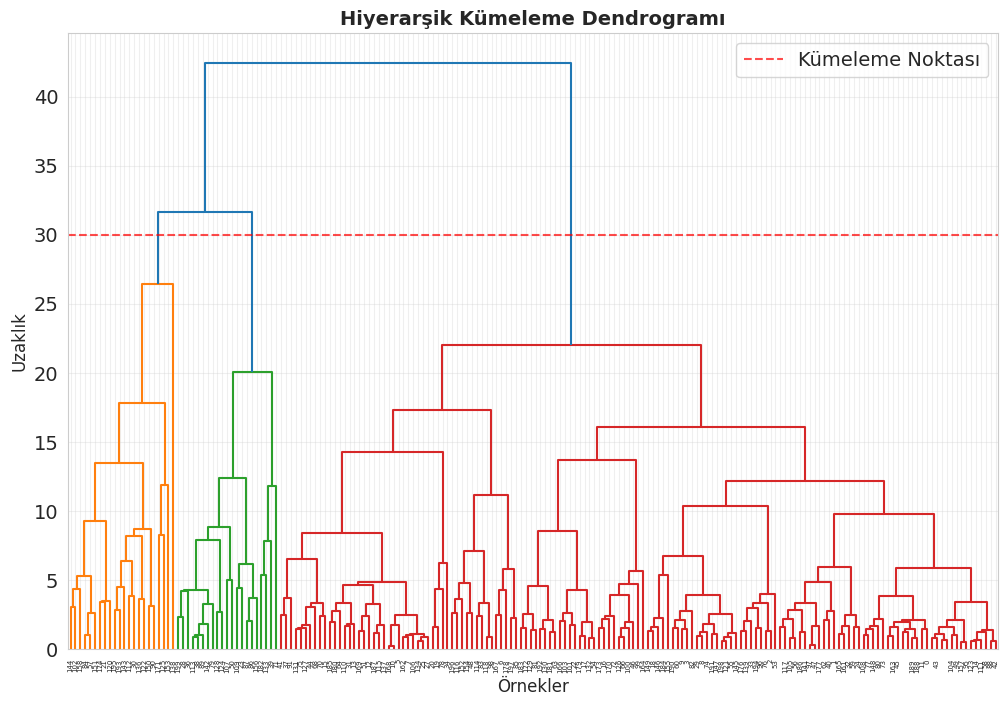

In [ ]:
plt.figure(figsize=(12,8))
linked = linkage(x_scaled[:200],method='ward')
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=False,truncate_mode='level',p=10)
plt.title('Hiyerarşik Kümeleme Dendrogramı', fontsize=14, fontweight='bold')
plt.xlabel('Örnekler', fontsize=12)
plt.ylabel('Uzaklık', fontsize=12)
plt.axhline(y=30,color='r',linestyle='--',alpha=0.7,label='Kümeleme Noktası')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Agglomerative
agg_clustering  =AgglomerativeClustering(n_clusters=optimal_k,linkage='ward')
agg_labels=agg_clustering.fit_predict(x_scaled)

print('Hiyerarşik (Agglomerative)Kümeleme Sonuçları:')
print(f'Kümeleme Sayısı: {optimal_k}')
print(f'Bağlantı Yöntemi :ward')
print(f'Silhoutte Skoru: {silhouette_score(x_scaled, agg_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, agg_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, agg_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())


Hiyerarşik (Agglomerative)Kümeleme Sonuçları:
Kümeleme Sayısı: 4
Bağlantı Yöntemi :ward
Silhoutte Skoru: 0.1547
Davies Bouldin Skoru: 1.7762
Calinski Harabasz Skoru: 1255.6049

 Kume dagilimi:
0     487
1    4668
2     864
3    2931
Name: count, dtype: int64


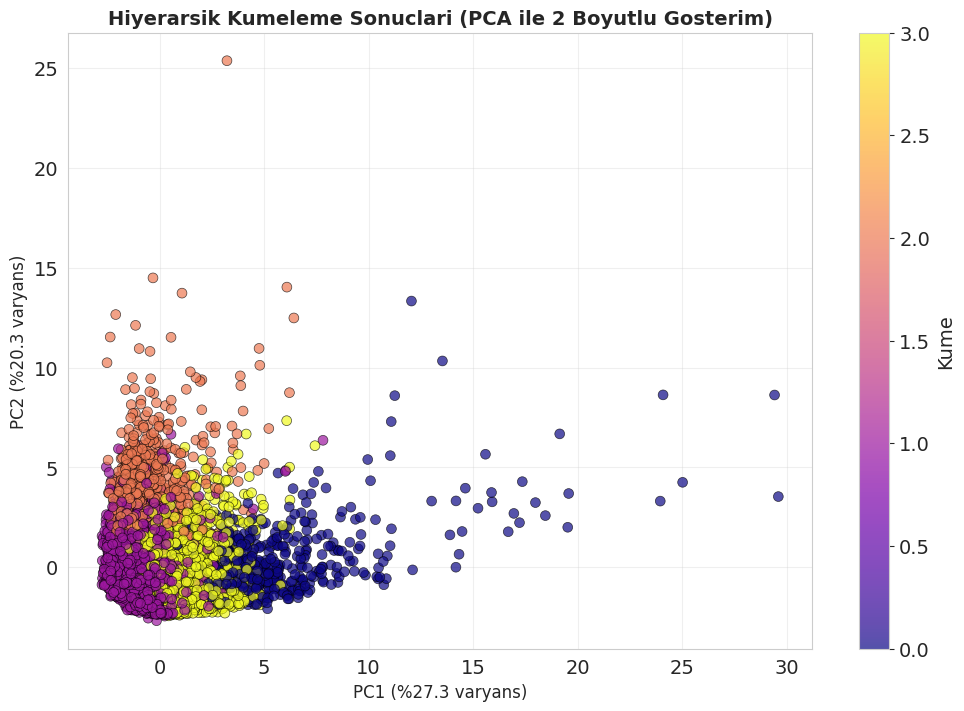

In [ ]:
# Hiyerarsik kumelerin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## **Dbscan**


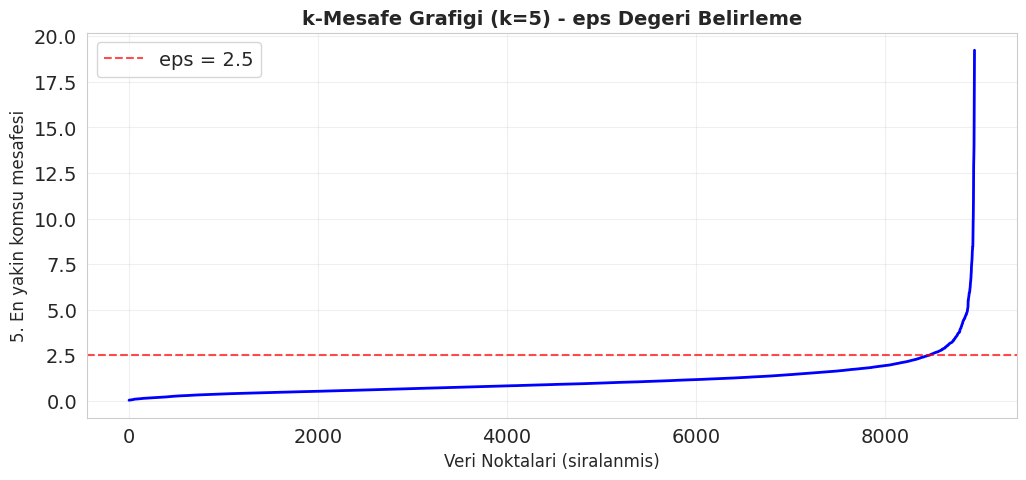

In [ ]:
#dbscan
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
dbscan= DBSCAN(eps=2.5,min_samples=5)
dbscan_labels=dbscan.fit_predict(x_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise =list(dbscan_labels).count(-1)

print('DBSCAN Kümeleme Sonuçları:')
print(f'Kümeleme Sayısı: {n_clusters_db}')
print(f'Gürültü Sayısı: {n_noise}')
print(f'Gürültü oranı: {n_noise/len(dbscan_labels):.4f}')

if n_clusters_db >1:
  print(f'Silhoutte Skoru: {silhouette_score(x_scaled, dbscan_labels):.4f}')
  print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, dbscan_labels):.4f}')
  print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, dbscan_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kümeleme Sonuçları:
Kümeleme Sayısı: 1
Gürültü Sayısı: 341
Gürültü oranı: 0.0381

 Kume dagilimi:
-1     341
 0    8609
Name: count, dtype: int64


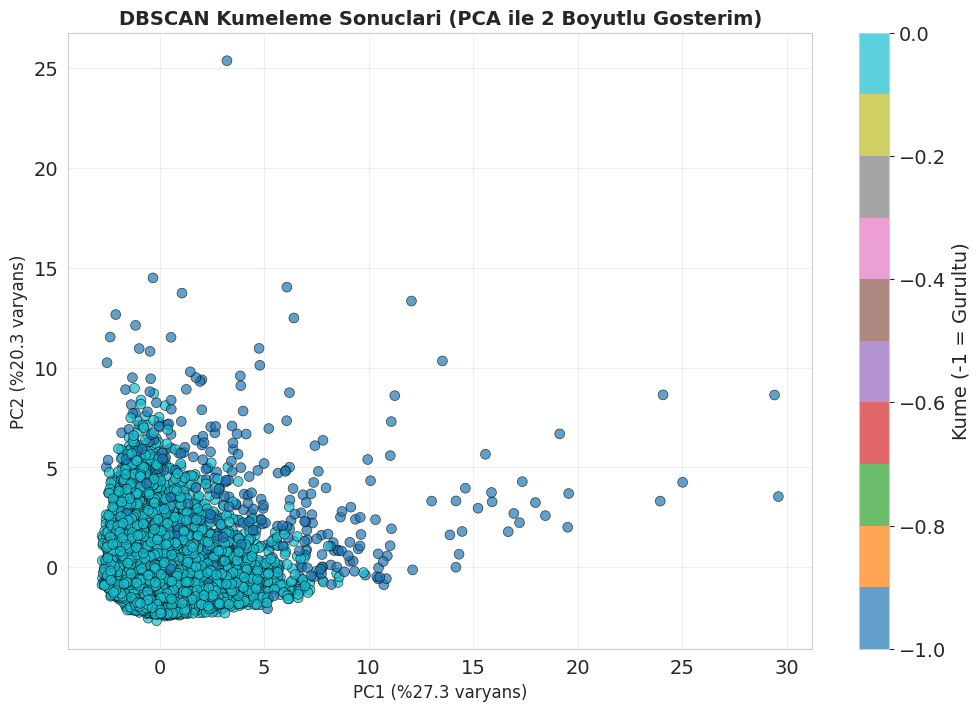

In [ ]:
# DBSCAN kumelerinin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# **Gaussian Mixture Model**

hiperparametreleri

* n_components: bileşen küme sayısı
* covariance_type:kovaryans tipi
* max_iter: maksimum iterasyon sayısı



In [ ]:
#gmm

gmm =GaussianMixture(n_components=optimal_k,covariance_type='full',max_iter=200)
gmm_labels=gmm.fit_predict(x_scaled)
gmm_probs=gmm.predict_proba(x_scaled)

print('GMM Kümeleme Sonuçları:')
print(f'Kümeleme Sayısı: {optimal_k}')
print(f'Sihoutte Skoru: {silhouette_score(x_scaled, gmm_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, gmm_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, gmm_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(gmm_labels).value_counts().sort_index())

GMM Kümeleme Sonuçları:
Kümeleme Sayısı: 4
Sihoutte Skoru: 0.0718
Davies Bouldin Skoru: 3.0748
Calinski Harabasz Skoru: 687.4266

 Kume dagilimi:
0    1294
1    2691
2     997
3    3968
Name: count, dtype: int64


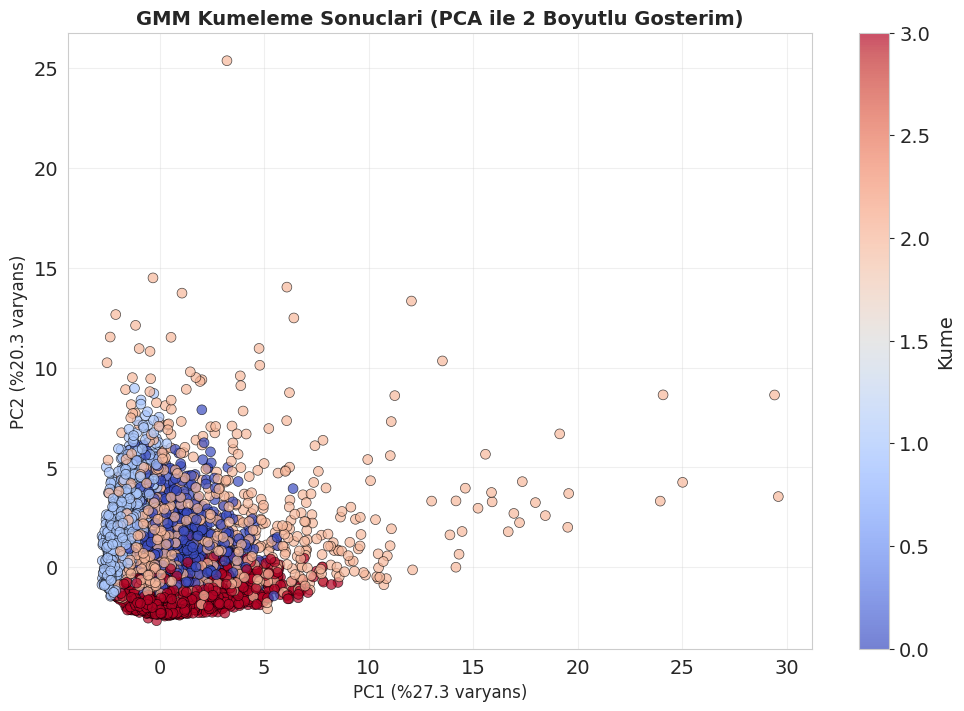

In [ ]:
# GMM kumelerinin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='coolwarm',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('GMM Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()